In [4]:
import pandas as pd
df1 = pd.read_csv("aviasales_calendar_flights.csv")
df2 = pd.read_csv("final_flights.csv")
print(df1.head())

  Класс обслуживания                Дата вылета Город отправления  \
0             Эконом  2025-03-02T12:05:00+06:00               ALA   
1             Эконом  2025-03-03T14:25:00+06:00               ALA   
2             Эконом  2025-03-04T14:45:00+06:00               ALA   
3             Эконом  2025-03-05T14:45:00+06:00               ALA   
4             Эконом  2025-03-06T15:50:00+06:00               ALA   

  Город назначения  Цена билета (USD) Авиакомпания  Номер рейса  \
0              NQZ                 86           DV          747   
1              NQZ                 79           DV          713   
2              NQZ                 74           FS         7055   
3              NQZ                 79           FS         7055   
4              NQZ                 71           DV         1703   

            Дата возвращения  Количество пересадок  
0  2025-03-03T12:05:00+06:00                     0  
1  2025-03-05T05:30:00+06:00                     0  
2  2025-03-05T00:15:00+

In [5]:
print(df2.head())

  Класс обслуживания Дата вылета Время вылета Время прилета Город отправления  \
0             эконом      23 мар        06:15         22:15            Алматы   
1             эконом      23 мар        11:40         16:10            Алматы   
2             эконом      23 мар        06:15         14:45            Алматы   
3             эконом      23 мар        06:15         11:45            Алматы   
4             эконом      23 мар        08:10      01:10+1д            Алматы   

  Город назначения  Цена билета      Авиакомпания Номер рейса  \
0           Лондон       133637  Pegasus Airlines      PC-101   
1           Лондон       224262        Air Astana      KC-663   
2           Лондон       133637  Pegasus Airlines      PC-101   
3           Лондон       159731  Pegasus Airlines      PC-101   
4           Лондон       162102  Azimuth Airlines     A4-5090   

   Количество пересадок  
0                     1  
1                     0  
2                     1  
3                 

In [6]:
df1['Дата вылета'] = pd.to_datetime(df1['Дата вылета'], errors='coerce', utc=True)
df1['Дата вылета'] = df1['Дата вылета'].dt.tz_convert(None)

df1['Дата_вылета'] = df1['Дата вылета'].dt.strftime('%d %b')   
df1['Время_вылета'] = df1['Дата вылета'].dt.strftime('%H:%M') 

df1 = df1.drop(columns=['Дата вылета'])

print(df1.head())

  Класс обслуживания Город отправления Город назначения  Цена билета (USD)  \
0             Эконом               ALA              NQZ                 86   
1             Эконом               ALA              NQZ                 79   
2             Эконом               ALA              NQZ                 74   
3             Эконом               ALA              NQZ                 79   
4             Эконом               ALA              NQZ                 71   

  Авиакомпания  Номер рейса           Дата возвращения  Количество пересадок  \
0           DV          747  2025-03-03T12:05:00+06:00                     0   
1           DV          713  2025-03-05T05:30:00+06:00                     0   
2           FS         7055  2025-03-05T00:15:00+06:00                     0   
3           FS         7055  2025-03-06T00:15:00+06:00                     0   
4           DV         1703  2025-03-27T14:55:00+06:00                     0   

  Дата_вылета Время_вылета  
0      02 Mar        

In [7]:
df1['Дата возвращения'] = pd.to_datetime(df1['Дата возвращения'], errors='coerce', utc=True)
df1['Дата возвращения'] = df1['Дата возвращения'].dt.tz_convert(None)
df1['Время прилета'] = df1['Дата возвращения'].dt.strftime('%H:%M')  # Пример: 12:05

df1 = df1.drop(columns=['Дата возвращения'])

print(df1.head())

  Класс обслуживания Город отправления Город назначения  Цена билета (USD)  \
0             Эконом               ALA              NQZ                 86   
1             Эконом               ALA              NQZ                 79   
2             Эконом               ALA              NQZ                 74   
3             Эконом               ALA              NQZ                 79   
4             Эконом               ALA              NQZ                 71   

  Авиакомпания  Номер рейса  Количество пересадок Дата_вылета Время_вылета  \
0           DV          747                     0      02 Mar        06:05   
1           DV          713                     0      03 Mar        08:25   
2           FS         7055                     0      04 Mar        08:45   
3           FS         7055                     0      05 Mar        08:45   
4           DV         1703                     0      06 Mar        09:50   

  Время прилета  
0         06:05  
1         23:30  
2       

In [8]:
print(df2.head())

  Класс обслуживания Дата вылета Время вылета Время прилета Город отправления  \
0             эконом      23 мар        06:15         22:15            Алматы   
1             эконом      23 мар        11:40         16:10            Алматы   
2             эконом      23 мар        06:15         14:45            Алматы   
3             эконом      23 мар        06:15         11:45            Алматы   
4             эконом      23 мар        08:10      01:10+1д            Алматы   

  Город назначения  Цена билета      Авиакомпания Номер рейса  \
0           Лондон       133637  Pegasus Airlines      PC-101   
1           Лондон       224262        Air Astana      KC-663   
2           Лондон       133637  Pegasus Airlines      PC-101   
3           Лондон       159731  Pegasus Airlines      PC-101   
4           Лондон       162102  Azimuth Airlines     A4-5090   

   Количество пересадок  
0                     1  
1                     0  
2                     1  
3                 

In [9]:
iata_to_city = {
    'ALA': 'Алматы',
    'NQZ': 'Астана',
    'CIT': 'Шымкент',
    'AKX': 'Актобе',
    'PWQ': 'Павлодар',
    'KSN': 'Костанай',
    'TDK': 'Талдыкорган',
    'URA': 'Уральск',
    'SCO': 'Актау',
    'HSA': 'Жезказган',
    'DMB': 'Тараз',
    'UKK': 'Усть-Каменогорск',
    'GUW': 'Атырау',
    'KZO': 'Кызылорда',
    'PLX': 'Семей'
}
df1['Город отправления'] = df1['Город отправления'].replace(iata_to_city)
df1['Город назначения'] = df1['Город назначения'].replace(iata_to_city)

print(df1[['Город отправления', 'Город назначения']].sample(5))

     Город отправления Город назначения
535             Астана          Уральск
1146            Актобе           Алматы
639              Актау           Алматы
745            Уральск           Алматы
1274            Актобе           Астана


In [10]:
usd_to_kzt = 495 
df1['Цена билета (KZT)'] = (df1['Цена билета (USD)'] * usd_to_kzt).astype(int)
#df1 = df1.drop(columns=['Цена билета (USD)'])
print(df1.head())

  Класс обслуживания Город отправления Город назначения Авиакомпания  \
0             Эконом            Алматы           Астана           DV   
1             Эконом            Алматы           Астана           DV   
2             Эконом            Алматы           Астана           FS   
3             Эконом            Алматы           Астана           FS   
4             Эконом            Алматы           Астана           DV   

   Номер рейса  Количество пересадок Дата_вылета Время_вылета Время прилета  \
0          747                     0      02 Mar        06:05         06:05   
1          713                     0      03 Mar        08:25         23:30   
2         7055                     0      04 Mar        08:45         18:15   
3         7055                     0      05 Mar        08:45         18:15   
4         1703                     0      06 Mar        09:50         08:55   

   Цена билета (KZT)  
0              42570  
1              39105  
2              36630  


In [11]:
airline_dict = {
    'DV': 'Scat Airlines',
    'FS': 'Qazaq Air',
    'IQ': 'Qatar Airways',
    'FZ': 'FlyDubai',
    'KC': 'Air Astana',
    '5W': 'Wizz Air',
    'J2': 'Azerbaijan Airlines'
}
df1['Авиакомпания'] = df1['Авиакомпания'].replace(airline_dict)
print(df1[['Авиакомпания']].sample(5))

      Авиакомпания
466  Scat Airlines
782     Air Astana
816      Qazaq Air
649  Scat Airlines
384      Qazaq Air


In [12]:
month_translation = {
    'Jan': 'янв', 'Feb': 'фев', 'Mar': 'мар', 'Apr': 'апр',
    'May': 'май', 'Jun': 'июн', 'Jul': 'июл', 'Aug': 'авг',
    'Sep': 'сен', 'Oct': 'окт', 'Nov': 'ноя', 'Dec': 'дек'
}

df1['Дата_вылета'] = df1['Дата_вылета'].replace(month_translation, regex=True)
print(df1[['Дата_вылета']].sample(5))

    Дата_вылета
74       13 июн
140      04 авг
606      25 апр
84       11 авг
747      06 апр


In [13]:
import re
def extract_flight_number(flight):
    return re.sub(r'\D', '', str(flight))
df2['Номер рейса'] = df2['Номер рейса'].apply(extract_flight_number)

print(df1[['Номер рейса']].sample(5))

      Номер рейса
1249          720
175           706
1088         7152
1022          726
1041          784


In [14]:
df1['Дата_вылета'] = df1['Дата_вылета'].str.lstrip('0')
print(df1[['Дата_вылета']].head())

  Дата_вылета
0       2 мар
1       3 мар
2       4 мар
3       5 мар
4       6 мар


In [15]:
print(df1.head())

  Класс обслуживания Город отправления Город назначения   Авиакомпания  \
0             Эконом            Алматы           Астана  Scat Airlines   
1             Эконом            Алматы           Астана  Scat Airlines   
2             Эконом            Алматы           Астана      Qazaq Air   
3             Эконом            Алматы           Астана      Qazaq Air   
4             Эконом            Алматы           Астана  Scat Airlines   

   Номер рейса  Количество пересадок Дата_вылета Время_вылета Время прилета  \
0          747                     0       2 мар        06:05         06:05   
1          713                     0       3 мар        08:25         23:30   
2         7055                     0       4 мар        08:45         18:15   
3         7055                     0       5 мар        08:45         18:15   
4         1703                     0       6 мар        09:50         08:55   

   Цена билета (KZT)  
0              42570  
1              39105  
2          

In [16]:
print(df2.head())

  Класс обслуживания Дата вылета Время вылета Время прилета Город отправления  \
0             эконом      23 мар        06:15         22:15            Алматы   
1             эконом      23 мар        11:40         16:10            Алматы   
2             эконом      23 мар        06:15         14:45            Алматы   
3             эконом      23 мар        06:15         11:45            Алматы   
4             эконом      23 мар        08:10      01:10+1д            Алматы   

  Город назначения  Цена билета      Авиакомпания Номер рейса  \
0           Лондон       133637  Pegasus Airlines         101   
1           Лондон       224262        Air Astana         663   
2           Лондон       133637  Pegasus Airlines         101   
3           Лондон       159731  Pegasus Airlines         101   
4           Лондон       162102  Azimuth Airlines       45090   

   Количество пересадок  
0                     1  
1                     0  
2                     1  
3                 

In [17]:
import pandas as pd
df1 = df1.rename(columns={
    'Дата_вылета': 'Дата вылета',
    'Время_вылета': 'Время вылета',
    'Цена билета (KZT)': 'Цена билета'
})

df2 = df2.rename(columns={
    'Класс обслуживания': 'Класс обслуживания',
    'Город отправления': 'Город отправления',
    'Город назначения': 'Город назначения',
    'Авиакомпания': 'Авиакомпания',
    'Номер рейса': 'Номер рейса',
    'Количество пересадок': 'Количество пересадок',
    'Дата вылета': 'Дата вылета',
    'Время вылета': 'Время вылета',
    'Время прилета': 'Время прилета',
    'Цена билета': 'Цена билета'
})

print("Колонки df1:", df1.columns)
print("Колонки df2:", df2.columns)

Колонки df1: Index(['Класс обслуживания', 'Город отправления', 'Город назначения',
       'Авиакомпания', 'Номер рейса', 'Количество пересадок', 'Дата вылета',
       'Время вылета', 'Время прилета', 'Цена билета'],
      dtype='object')
Колонки df2: Index(['Класс обслуживания', 'Дата вылета', 'Время вылета', 'Время прилета',
       'Город отправления', 'Город назначения', 'Цена билета', 'Авиакомпания',
       'Номер рейса', 'Количество пересадок'],
      dtype='object')


In [18]:
new_column_order = [
    'Класс обслуживания', 'Дата вылета', 'Время вылета', 'Время прилета',
       'Город отправления', 'Город назначения', 'Цена билета', 'Авиакомпания',
       'Номер рейса', 'Количество пересадок'
]
df1 = df1[new_column_order]
print(df1.head())

  Класс обслуживания Дата вылета Время вылета Время прилета Город отправления  \
0             Эконом       2 мар        06:05         06:05            Алматы   
1             Эконом       3 мар        08:25         23:30            Алматы   
2             Эконом       4 мар        08:45         18:15            Алматы   
3             Эконом       5 мар        08:45         18:15            Алматы   
4             Эконом       6 мар        09:50         08:55            Алматы   

  Город назначения  Цена билета   Авиакомпания  Номер рейса  \
0           Астана        42570  Scat Airlines          747   
1           Астана        39105  Scat Airlines          713   
2           Астана        36630      Qazaq Air         7055   
3           Астана        39105      Qazaq Air         7055   
4           Астана        35145  Scat Airlines         1703   

   Количество пересадок  
0                     0  
1                     0  
2                     0  
3                     0  
4   

In [19]:
print(df2.head())

  Класс обслуживания Дата вылета Время вылета Время прилета Город отправления  \
0             эконом      23 мар        06:15         22:15            Алматы   
1             эконом      23 мар        11:40         16:10            Алматы   
2             эконом      23 мар        06:15         14:45            Алматы   
3             эконом      23 мар        06:15         11:45            Алматы   
4             эконом      23 мар        08:10      01:10+1д            Алматы   

  Город назначения  Цена билета      Авиакомпания Номер рейса  \
0           Лондон       133637  Pegasus Airlines         101   
1           Лондон       224262        Air Astana         663   
2           Лондон       133637  Pegasus Airlines         101   
3           Лондон       159731  Pegasus Airlines         101   
4           Лондон       162102  Azimuth Airlines       45090   

   Количество пересадок  
0                     1  
1                     0  
2                     1  
3                 

In [27]:
df_merged = pd.concat([df1, df2], ignore_index=True)
df_merged.to_csv("merged_data.csv", index=False)
print("Объединенные данные сохранены в merged_data.csv")

Объединенные данные сохранены в merged_data.csv


In [31]:
print(df_merged.sample(5))

     Класс обслуживания Дата вылета Время вылета Время прилета  \
8226             эконом      26 фев        20:25         12:55   
326              Эконом      30 апр        05:20         16:50   
5295             Эконом       9 мар        20:10         01:45   
3216             эконом      28 мар        17:25         21:25   
191              Эконом       6 апр        10:25         18:30   

     Город отправления Город назначения  Цена билета             Авиакомпания  \
8226            Алматы          Бангкок       205771  China Southern Airlines   
326             Астана           Алматы        28215            Scat Airlines   
5295            Актобе            Актау        49500                Qazaq Air   
3216            Астана          Стамбул        98822               Air Astana   
191             Алматы          Уральск        97515                Qazaq Air   

      Номер рейса  Количество пересадок  
8226         6012                     2  
326           714               

In [35]:
print(df_merged.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11566 entries, 0 to 11565
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Класс обслуживания    11566 non-null  object
 1   Дата вылета           11566 non-null  object
 2   Время вылета          11566 non-null  object
 3   Время прилета         11566 non-null  object
 4   Город отправления     11566 non-null  object
 5   Город назначения      11566 non-null  object
 6   Цена билета           11566 non-null  int64 
 7   Авиакомпания          11566 non-null  object
 8   Номер рейса           11566 non-null  int64 
 9   Количество пересадок  11566 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 903.7+ KB
None


In [36]:
df_merged = df_merged.drop_duplicates()
print(f"Осталось {df_merged.shape[0]} строк после удаления дубликатов")

Осталось 10877 строк после удаления дубликатов


In [37]:
print(df_merged.isnull().sum())

Класс обслуживания      0
Дата вылета             0
Время вылета            0
Время прилета           0
Город отправления       0
Город назначения        0
Цена билета             0
Авиакомпания            0
Номер рейса             0
Количество пересадок    0
dtype: int64


In [38]:
print(df_merged.dtypes)

Класс обслуживания      object
Дата вылета             object
Время вылета            object
Время прилета           object
Город отправления       object
Город назначения        object
Цена билета              int64
Авиакомпания            object
Номер рейса              int64
Количество пересадок     int64
dtype: object


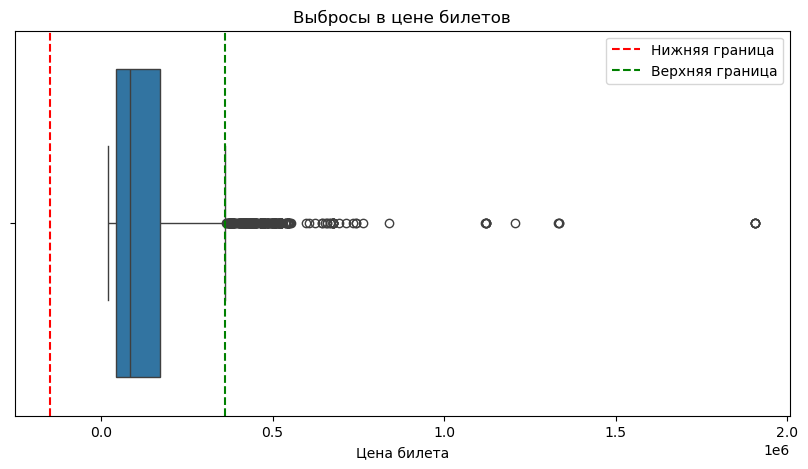

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)  
    Q3 = df[column].quantile(0.75)  
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR  
    upper_bound = Q3 + 1.5 * IQR  

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_price, lower_price, upper_price = detect_outliers_iqr(df_merged, 'Цена билета')

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_merged['Цена билета'])
plt.axvline(lower_price, color='r', linestyle='dashed', label='Нижняя граница')
plt.axvline(upper_price, color='g', linestyle='dashed', label='Верхняя граница')
plt.legend()
plt.title("Выбросы в цене билетов")
plt.show()

In [44]:
df_merged = df_merged[(df_merged['Цена билета'] >= lower_price) & (df_merged['Цена билета'] <= upper_price)]
outliers_removed = outliers_price.shape[0]
print(f"Удалено выбросов: {outliers_removed}")

df_merged.to_csv("drop_outliers.csv", index=False)
print("Файл drop_outliers.csv успешно сохранен.")

Удалено выбросов: 280
Файл drop_outliers.csv успешно сохранен.


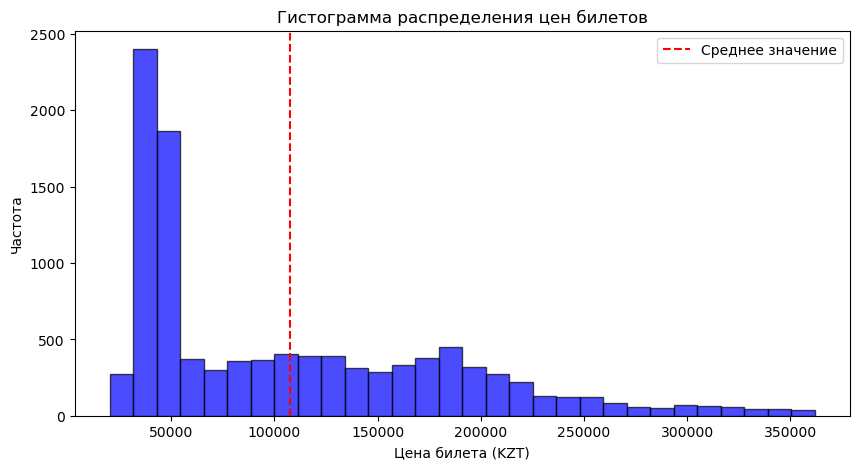

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df_cleaned = pd.read_csv("drop_outliers.csv")

plt.figure(figsize=(10, 5))
plt.hist(df_cleaned['Цена билета'], bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(df_cleaned['Цена билета'].mean(), color='red', linestyle='dashed', label='Среднее значение')
plt.xlabel("Цена билета (KZT)")
plt.ylabel("Частота")
plt.title("Гистограмма распределения цен билетов")
plt.legend()
plt.show()

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_columns = ["Цена билета", "Номер рейса", "Количество пересадок"]
df_cleaned[num_columns] = scaler.fit_transform(df_cleaned[num_columns])
print(df_cleaned.sample(5))

     Класс обслуживания Дата вылета Время вылета Время прилета  \
9585             Эконом      15 Aug        11:45         13:45   
2363             эконом       6 апр        19:00         19:10   
5045             эконом       4 мар        06:40         11:20   
9161             Эконом      04 Aug        12:00         13:00   
6094             эконом      12 мар        23:10         21:20   

     Город отправления  Город назначения  Цена билета        Авиакомпания  \
9585             Актау            Атырау     0.080998       Scat Airlines   
2363            Алматы             Токио     0.427958           Airasia X   
5045            Алматы           Стамбул     0.400597    Turkish Airlines   
9161         Караганда  Усть-Каменогорск     0.068892          FlyArystan   
6094            Алматы            Москва     0.268677  Uzbekistan Airways   

      Номер рейса  Количество пересадок  
9585     0.038295              0.000000  
2363     0.099450              0.666667  
5045     0.016

In [50]:
df_cleaned = df_cleaned.drop(columns=["Номер рейса", "Класс обслуживания"])
print(df_cleaned.sample(5))

     Дата вылета Время вылета Время прилета Город отправления  \
9893      16 May        03:15         05:15            Астана   
5522       6 мар        18:00         10:20            Астана   
5861      28 фев        08:20      03:10+1д            Алматы   
9117      25 Aug        23:45         00:45             Актау   
7235      21 фев        23:15      01:00+1д            Алматы   

     Город назначения  Цена билета             Авиакомпания  \
9893    Петропавловск     0.055705            Scat Airlines   
5522            Дубай     0.464155               Air Astana   
5861           Москва     0.684672                     AJet   
9117         Костанай     0.071271            Scat Airlines   
7235          Бангкок     0.543276  China Southern Airlines   

      Количество пересадок  
9893              0.000000  
5522              0.666667  
5861              0.666667  
9117              0.000000  
7235              0.666667  


In [51]:
df_cleaned.to_csv("cleaned_data.csv", index=False)
print("Файл cleaned_data.csv успешно сохранен.")

Файл cleaned_data.csv успешно сохранен.
